# Notebook 06: SHAP Analysis
Model interpretability using SHAP (SHapley Additive exPlanations)

## Cell 1 — Imports

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import pandas as pd
from src.data.data_loader import (
    load_config,
    load_dataset,
    sample_dataset
)
from src.data.preprocessing import (
    basic_preprocessing_pipeline
)
from src.features.feature_engineering import (
    feature_engineering_pipeline
)
from src.features.encoder import (
    encode_categorical_columns
)
from src.models.train_test_split import (
    temporal_train_test_split,
    split_features_target
)
from src.models.smote_pipeline import (
    apply_smote
)
from src.models.boosting_models import (
    train_xgboost
)
from src.visualization.shap_visualizer import (
    create_tree_explainer,
    compute_shap_values,
    plot_shap_summary,
    plot_shap_dependence,
    plot_shap_waterfall
)
from src.evaluation.feature_importance import (
    compute_mean_shap_importance
)

## Cell 2 — Load + Prepare Dataset

In [2]:
config = load_config()
df = load_dataset(config)
df = sample_dataset(df, config)
df = basic_preprocessing_pipeline(df)
df = feature_engineering_pipeline(df)
train_df, test_df = temporal_train_test_split(df)
X_train, X_test, y_train, y_test = split_features_target(
    train_df,
    test_df
)
X_train, X_test, encoders = encode_categorical_columns(
    X_train,
    X_test
)
X_train_smote, y_train_smote = apply_smote(
    X_train,
    y_train
)

print(f"✓ Data prepared successfully!")
print(f"  Training set (SMOTE): {X_train_smote.shape}")
print(f"  Test set: {X_test.shape}")


Loading dataset from:
/Users/nurnafisfuad/Desktop/AccidentXAI/data/raw/US_Accidents_March23.csv


Dataset loaded successfully.


Sampling 100000 rows...


Starting preprocessing pipeline...

Converting Start_Time to datetime format...
Removed 85 duplicate rows.

Selected relevant columns.

Dropping high-missing columns:

[]

Missing values handled successfully.

Preprocessing completed successfully.


Starting feature engineering pipeline...

Creating temporal features...

Creating rush-hour feature...

Creating night-driving feature...

Simplifying target variable...


Feature engineering completed.


Performing temporal split...

Train Shape: (71919, 30)
Test Shape: (16318, 30)

Separating features and target...

X_train shape: (71919, 29)
X_test shape: (16318, 29)

Encoding categorical columns...

Encoding completed.


Applying SMOTE...

Before SMOTE:

Counter({0: 54138, 1: 17781})

After SMOTE:

Counter({0: 54138, 1: 54138})
✓ Data prepared successfully!
  Training set (SMOTE): (1

## Cell 3 — Train XGBoost

In [3]:
xgb_model = train_xgboost(
    X_train_smote,
    y_train_smote
)

print("✓ XGBoost model trained successfully")


Training XGBoost...

XGBoost training completed.

✓ XGBoost model trained successfully


## Cell 4 — Create SHAP Sample

In [4]:
X_shap_sample = X_test.sample(
    n=1000,
    random_state=42
)
X_shap_sample.shape

(1000, 29)

## Cell 5 — IMPORTANT RESEARCH INSIGHT

> **Never compute SHAP on entire huge datasets initially.**
> 
> SHAP is computationally expensive.
> 
> Sampling is common and acceptable practice.

## Cell 6 — Create Explainer

In [5]:
explainer = create_tree_explainer(
    xgb_model
)

print("✓ SHAP TreeExplainer created")


Creating SHAP explainer...

✓ SHAP TreeExplainer created


## Cell 7 — Compute SHAP Values

In [6]:
shap_values = compute_shap_values(
    explainer,
    X_shap_sample
)

print("✓ SHAP values computed successfully")


Computing SHAP values...

SHAP computation completed.

✓ SHAP values computed successfully


## Cell 8 — SHAP Summary Plot


Generating SHAP summary plot...



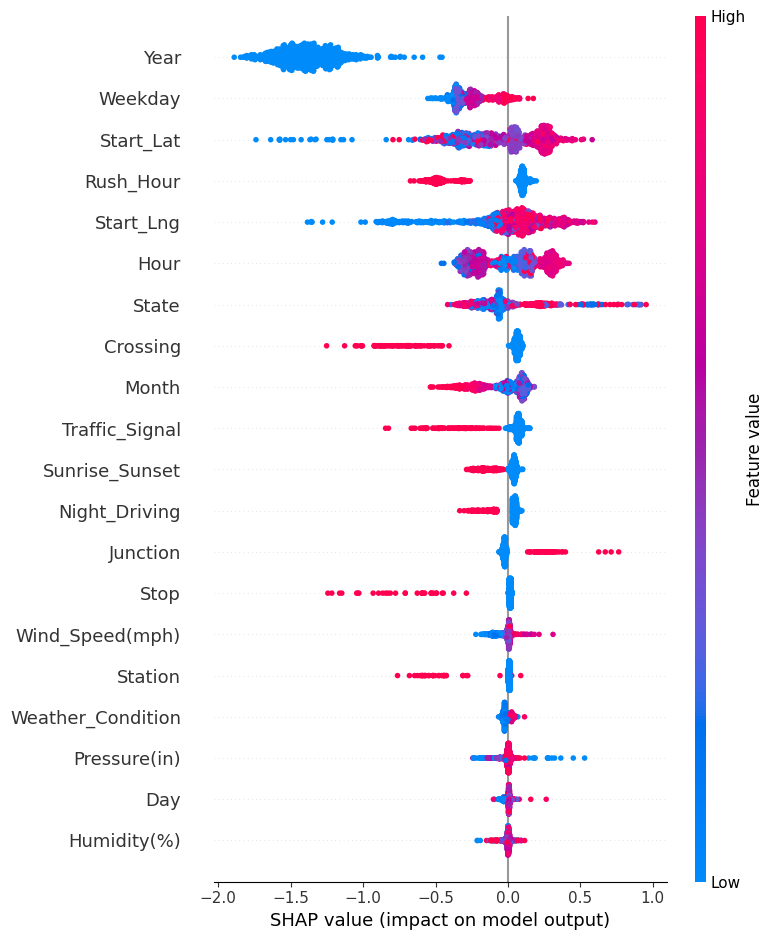

In [7]:
plot_shap_summary(
    shap_values,
    X_shap_sample
)

## Cell 9 — What You Should Observe

**Features at top are most influential.**

| Color | Meaning |
|-------|---------|
| Red | high feature value |
| Blue | low feature value |

**Horizontal spread shows impact magnitude.**

## Cell 10 — Feature Importance Table

In [8]:
importance_df = compute_mean_shap_importance(
    shap_values,
    X_shap_sample
)
importance_df.head(15)

,Feature,Mean_SHAP_Importance
22,Year,1.380363
26,Weekday,0.255342
20,Start_Lat,0.248307
27,Rush_Hour,0.239316
21,Start_Lng,0.207054
25,Hour,0.200152
19,State,0.162831
8,Crossing,0.126542
23,Month,0.126166
17,Traffic_Signal,0.101360


## Cell 11 — Dependence Plot


Generating dependence plot for Visibility(mi)...



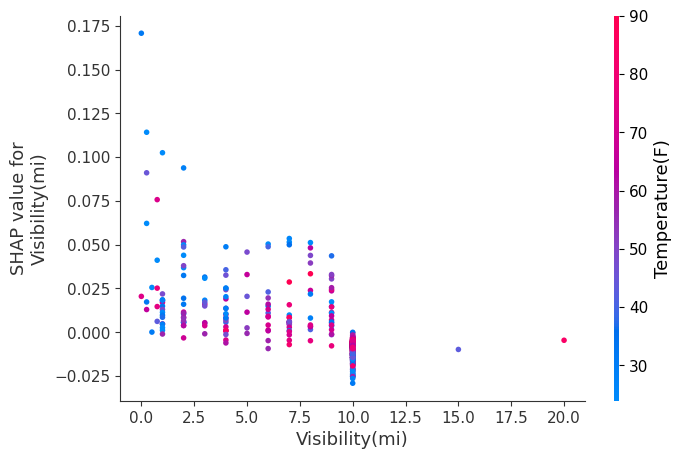

In [9]:
plot_shap_dependence(
    shap_values,
    X_shap_sample,
    feature_name="Visibility(mi)"
)

## Cell 12 — What Dependence Plot Means

You are analyzing:

**How changing visibility changes model prediction**

This becomes scientifically interesting.

---

**Interpretation Guide:**
- X-axis: Feature value (Visibility in miles)
- Y-axis: SHAP value (Impact on prediction)
- Positive SHAP: Increases accident severity
- Negative SHAP: Decreases accident severity
- Color (if shown): Secondary feature interaction

## Cell 13 — Local Explanation


Generating SHAP waterfall plot...



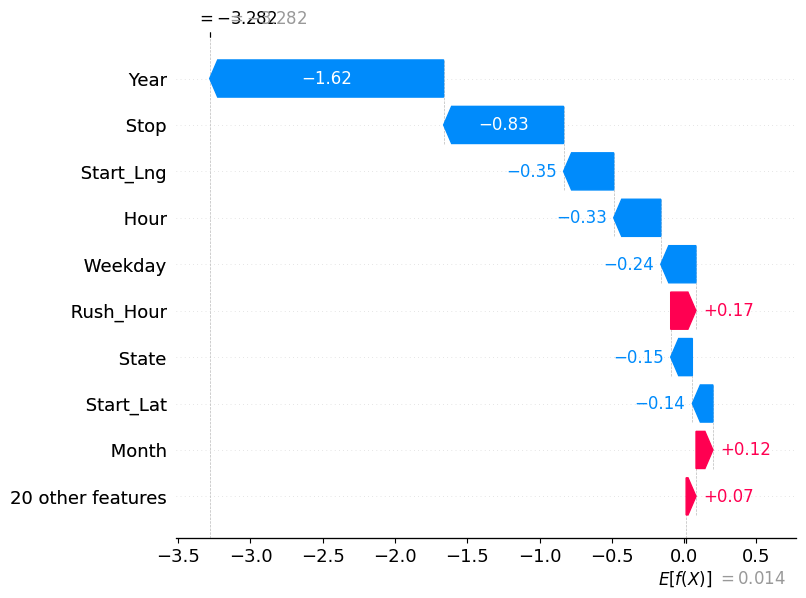

In [10]:
plot_shap_waterfall(
    explainer,
    shap_values,
    X_shap_sample,
    sample_index=0
)

## Optional Cell 14 — Additional SHAP Analysis

Explore more SHAP visualizations

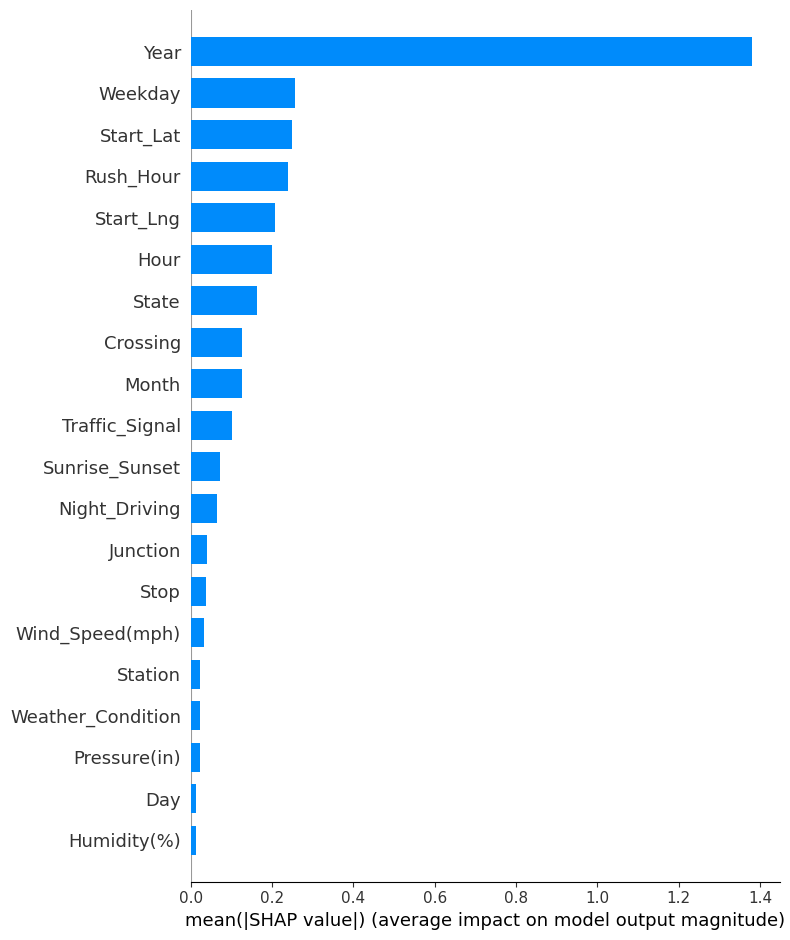

<Figure size 640x480 with 0 Axes>

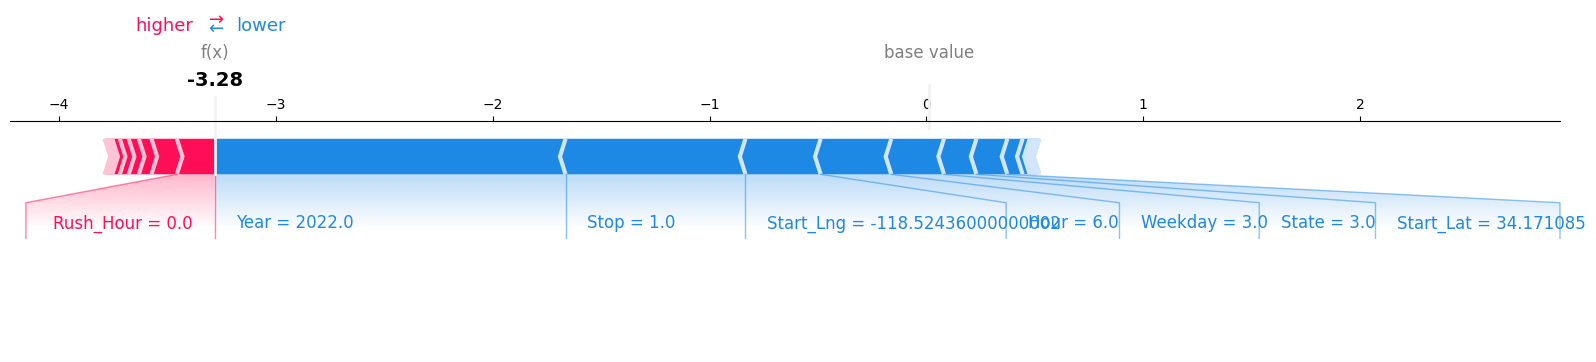

In [11]:
# Bar plot of feature importance
import matplotlib.pyplot as plt
import shap

# Summary bar plot
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar")
plt.tight_layout()
plt.show()

# Force plot for first prediction
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_shap_sample.iloc[0,:], matplotlib=True)
plt.show()